In [5]:
!pip install pandas numpy matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 2.0 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.3 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.3 MB 2.0 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.3 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.3 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.3 MB 1.8 MB/s eta 0:00:06
   --------- ------------------------------ 2.6/11.3 MB 1.7 MB/s eta 0

In [10]:
!pip install scikit-learn


  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 1.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/8.9 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/8.9 MB 2.1 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.9 MB 2.0 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.9 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.9 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/8.9 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.4/8.9 MB 1.7 MB/s eta 0:00:04
   ----------------- ---------------------- 3.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv('atlas-higgs-challenge-2014-v2.csv.gz')

In [14]:
df.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


In [15]:
df.isnull().values.any()

np.False_

In [16]:
print(df.dtypes)

EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_leading_eta      

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop(['Label','KaggleSet','EventId', 'Weight','KaggleWeight'],axis=1)

In [19]:
y = df['Label'].map({'s': 1, 'b': 0})

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)  


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8398880524051623
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88    161604
           1       0.79      0.72      0.75     83868

    accuracy                           0.84    245472
   macro avg       0.83      0.81      0.82    245472
weighted avg       0.84      0.84      0.84    245472

Confusion Matrix:
 [[146056  15548]
 [ 23755  60113]]


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


C:\Users\sreen\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.6383 - loss: 3.7563 - val_accuracy: 0.7101 - val_loss: 0.5654
Epoch 2/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.7106 - loss: 0.5481 - val_accuracy: 0.7590 - val_loss: 0.4998
Epoch 3/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7574 - loss: 0.4970 - val_accuracy: 0.7844 - val_loss: 0.4875
Epoch 4/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7697 - loss: 0.4814 - val_accuracy: 0.7885 - val_loss: 0.4709
Epoch 5/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7722 - loss: 0.4748 - val_accuracy: 0.7608 - val_loss: 0.4788
Epoch 6/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7773 - loss: 0.4684 - val_accuracy: 0.7841 - val_loss: 0.4656
Epoch 7/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.7815 - loss: 0.4603 - val_accuracy: 0.7912 - val_loss: 0.4530
Epoch 8/50
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.7859 - loss: 0

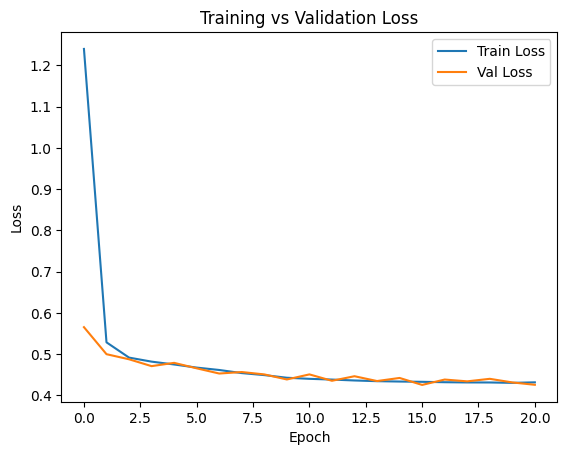

In [31]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate
#print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
#📈 Optional: Plot Training History
#python
#Copy
#Edit
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

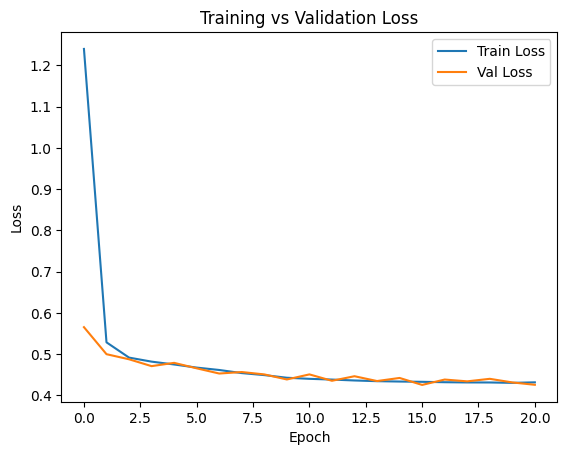

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

7671/7671 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
MAE  : 0.3005
RMSE : 0.3698
R2 Score: 0.3921


7671/7671 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


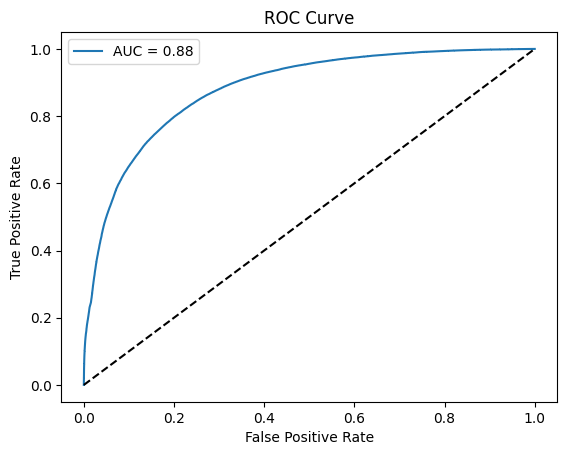

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob = model.predict(X_test).flatten()  # flatten ensures 1D array

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [36]:
!pip install xgboost


  Using cached xgboost-3.0.2-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.2-py3-none-win_amd64.whl (150.0 MB)


In [37]:
import xgboost as xgb

In [38]:
from sklearn.metrics import roc_auc_score

In [39]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)


C:\Users\sreen\anaconda3\envs\tf_env\lib\site-packages\xgboost\training.py:183: UserWarning: [00:25:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [40]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [41]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.9109179129265481


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88    161604
           1       0.79      0.73      0.76     83868

    accuracy                           0.84    245472
   macro avg       0.83      0.82      0.82    245472
weighted avg       0.84      0.84      0.84    245472

Confusion Matrix:
 [[145082  16522]
 [ 22257  61611]]


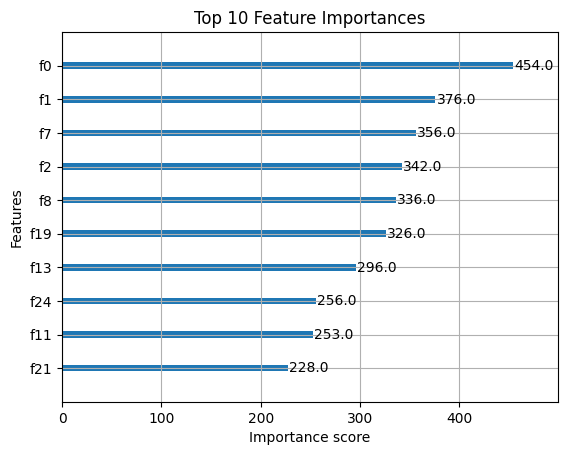

In [42]:
y_predxg = model.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_predxg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predxg))

# Step 10: Plot Feature Importance
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.show()

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# First, compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Then plot it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

def ams_score(y_true, y_pred, weights):
    """
    Compute the AMS score.
    
    Parameters:
    y_true   -- True binary labels (1 for signal, 0 for background)
    y_pred   -- Predicted binary labels (1 for signal, 0 for background)
    weights  -- Event weights associated with each observation
    
    Returns:
    AMS score (float)
    """
    assert len(y_true) == len(y_pred) == len(weights)
    
    # s = sum of weights for correctly predicted signal
    s = np.sum(weights[(y_true == 1) & (y_pred == 1)])
    
    # b = sum of weights for background predicted as signal
    b = np.sum(weights[(y_true == 0) & (y_pred == 1)])
    
    # Safety constant to avoid division by zero or log(0)
    br = 10.0
    
    # AMS formula
    if b + br == 0:
        return 0
    else:
        return np.sqrt(2 * ((s + b + br) * np.log(1.0 + s / (b + br)) - s))


In [ ]:
weights = X_test['Weight'].values


In [60]:
ams = ams_score(y_test, y_pred, weights)

In [62]:
ams

30.45646133710448